<a href="https://colab.research.google.com/github/fcastellanosp/MINE-4206_202510_AML/blob/main/Laboratorios/Laboratorio_1/MINE_4206_202510_AML_Lab1_S2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

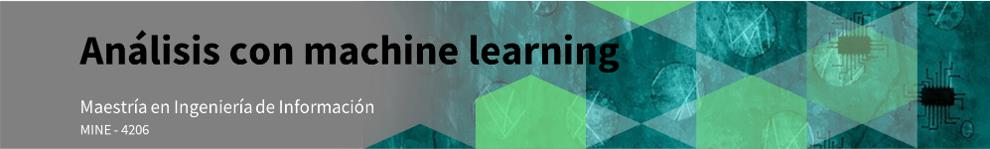

**Tutores**.
* Nicolás Tibatá Casteñeda.
* Fabián Camilo Castellanos P.

#Tabla de contenido

[Contexto y objetivos](#scrollTo=1ttPWxrdUToF&line=1&uniqifier=1)<br>
[0. Instalación e importación de librerías](#scrollTo=VjLUweXbT9aj)<br>
[1. Introducción a los datos](#scrollTo=VjLUweXbT9aj)<br>
[2. Modelamiento](#scrollTo=RI3ETff7Pw_b)<br>
&nbsp;&nbsp;[2.0. Pipeline](#scrollTo=bmJ3yv1wRbVj)<br>
&nbsp;&nbsp;[2.1. Regresión Lineal](#scrollTo=IQj4VAfIPFHL)<br>
&nbsp;&nbsp;[2.2. Regresión Polinomial](#scrollTo=DsUSvtsVQabX)<br>
&nbsp;&nbsp;[2.3. Regresión Lineal con regularización L1](#scrollTo=Hl7ToBUkRGE4)<br>
&nbsp;&nbsp;[2.4. Búsqueda del mejor modelo](#scrollTo=H-PxRpwHRGNR)<br>
[3. Preguntas.](#scrollTo=abi6z7h4Qam9)<br>

---
# Contexto y objetivos

Las emisiones de CO2 tienen importantes impactos ambientales. La acumulación de CO2 en la atmósfera contribuye al efecto invernadero, atrapando calor y provocando el calentamiento global. Esto conduce a diversos efectos adversos, incluido el aumento de las temperaturas globales, el aumento del nivel del mar, cambios en los patrones climáticos y alteraciones de los ecosistemas. Las consecuencias a largo plazo del cambio climático pueden afectar negativamente la salud humana, la agricultura, la biodiversidad y los sistemas socioeconómicos.

Por tanto, reducir las emisiones de CO2 es crucial para mitigar el cambio climático y minimizar sus efectos nocivos sobre el medio ambiente y el bienestar humano. Esto implica hacer la transición a fuentes de energía más limpias y renovables, mejorar la eficiencia energética, adoptar prácticas sostenibles y promover esfuerzos de conservación.
El set de datos reúne información de emisiones de automotores e información de consumo de combustible.

#### **Con apoyo del negocio ha sido posible elaborar el siguiente diccionario de datos**:

| ATRIBUTO | DEFINICIÓN |
| :- | :- |
| **Make** | Nombre del fabricante de automotores. |
| **Model** | Modelo del automotor. |
| **Vehicle Class** | Clase de vehículo. |
| **Engine Size (L)** | Tamaño del motor. Las unidades están expresadas en litros. |
| **Transmission** | Tipo de transmisión del vehículo, automática o manual. |
| **Fuel Type** | Tipo de combustible: *Regular Gasoline* (X), *Premium Gasoline* (Z), *Ethanol* (E), *Diesel* (D), *Natural Gas* (N). |
| **Fuel Consumption City (L/100km)** | Consumo del vehículo en ciudad. Las unidades están expresadas en litros por kilómetro. |
| **Fuel Consumption Hwy (L/100 km)** | Consumo del vehículo en carretera. Las unidades están expresadas en litros por kilómetro. |
| **Fuel Consumption Comb (L/100 km)** | Consumo del vehículo en ciudad y en carretera. Las unidades están expresadas en litros por kilómetro.|
| **Fuel Consumption Comb (mpg)** | Consumo del vehículo en ciudad y en carretera. Las unidades están expresadas en millas por galón. |
| **CO2 Emissions(g/km)** | Cantidad de gramos emitidos de C02 por kilometro. |



#### **Objetivos**:
* Resolver un problema de Aprendizaje de Datos.
* Revisar los conceptos básicos de una Regresión Lineal.
* Familiarizarse con la herramienta de Jupyter Notebook.

**Datos**: Información obtenida de [CO2 Emissions](https://www.kaggle.com/datasets/bhuviranga/co2-emissions).

---
# 0. Instalación e importación de librerías

Las librerías que se van a utilizar, por lo general se tienen que instalar desde consola mediante el comando `pip`, de esta forma estarán disponibles  dentro del ambiente donde se está ejecutando el Notebook. Sin embargo, si se encuentran en un ambiente compartido como Google Colab o simplemente desean realizar la instalación de los paquetes desde el mismo notebook lo pueden hacer con el siguiente código

```
!pip install [nom_paquete]
```

Por ejemplo:
```
!pip install pandas
```

In [ ]:
!pip install ydata-profiling plotly kaggle -q # -q quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 31.4 MB/s eta 0:00:00


In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización de datos
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Analisis profundo de datos
from ydata_profiling import ProfileReport

#Entrenamiento del modelo
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector

# Google Colab
from google.colab import files

De ahora en adelante subiremos los datos directamente de Kaggle siempre y cuando sean provenientes de dicha plataforma. Una forma sencilla es como la que se ejecuta a continuación:

[Easiest way to download kaggle data in Google Colab](https://www.kaggle.com/discussions/general/74235)

In [ ]:
files.upload() # Cargamos el Kaggle.json (API)

!ls -lha kaggle.json
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download bhuviranga/co2-emissions

-rw-r--r-- 1 root root 70 Feb  3 17:58 kaggle.json
chmod: cannot access '/root/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/bhuviranga/co2-emissions
License(s): DbCL-1.0
co2-emissions.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
ROOT_DIR = '/content'
DATASET_NAME = 'co2-emissions'

%cd {ROOT_DIR}
!unzip {DATASET_NAME}.zip -d {ROOT_DIR}/{DATASET_NAME}

/content
Archive:  co2-emissions.zip
  inflating: /content/co2-emissions/CO2 Emissions.csv  


In [ ]:
data = pd.read_csv(f'{ROOT_DIR}/{DATASET_NAME}/CO2 Emissions.csv')

In [ ]:
data

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232


---
# 1. Introducción a los datos

In [ ]:
train, test = train_test_split(data, test_size=0.2, random_state=19)
train.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3146,PORSCHE,CAYMAN GT4,TWO-SEATER,3.8,6,M6,Z,13.3,10.1,11.8,24,277
4639,CHRYSLER,300 AWD FFV,FULL-SIZE,3.6,6,A8,X,12.8,8.7,11.0,26,258
5457,ACURA,MDX Hybrid AWD,SUV - SMALL,3.0,6,AM7,Z,9.1,9.0,9.0,31,210
1003,TOYOTA,TACOMA,PICKUP TRUCK - SMALL,4.0,6,M6,X,14.5,11.3,13.1,22,301
5583,BUICK,Envision AWD,SUV - SMALL,2.5,4,A6,X,11.1,8.6,10.0,28,234


In [ ]:
report = train.profile_report(html={'style':{'full_width':True}})
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Variables a eliminar
drop_fields = ['Model', 'Vehicle Class']

# Variable objetivo
target_feature = 'CO2 Emissions(g/km)'

# Variables categoricas
cat_features = ['Make', 'Transmission', 'Fuel Type']

In [ ]:
# Preprocess
def preprocess(df):
  df = df.drop_duplicates() # Eliminamos duplicados
  df = df.drop(drop_fields, axis = 1) # Eliminamos columnas que no vamos a usar
  X_data, y_variable = df.drop([target_feature], axis=1), df[target_feature]
  return X_data, y_variable

In [ ]:
X_train, y_train = preprocess(train)
display(X_train)
display(y_train)

,Make,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
3146,PORSCHE,3.8,6,M6,Z,13.3,10.1,11.8,24
4639,CHRYSLER,3.6,6,A8,X,12.8,8.7,11.0,26
5457,ACURA,3.0,6,AM7,Z,9.1,9.0,9.0,31
1003,TOYOTA,4.0,6,M6,X,14.5,11.3,13.1,22
5583,BUICK,2.5,4,A6,X,11.1,8.6,10.0,28
...,...,...,...,...,...,...,...,...,...
1043,VOLKSWAGEN,2.0,4,A6,D,8.1,6.4,7.4,38
5032,LAMBORGHINI,5.2,10,AM7,Z,17.2,12.3,15.0,19
1378,CHRYSLER,3.6,6,A9,X,12.8,8.1,10.7,26
757,MERCEDES-BENZ,5.5,8,AS7,Z,15.5,11.0,13.5,21


,CO2 Emissions(g/km)
3146,277
4639,258
5457,210
1003,301
5583,234
...,...
1043,198
5032,350
1378,246
757,310


In [ ]:
# Definamos las variables numericas
num_features = list(set(X_train.columns) - set(cat_features))
num_features

['Fuel Consumption Hwy (L/100 km)',
 'Engine Size(L)',
 'Fuel Consumption City (L/100 km)',
 'Cylinders',
 'Fuel Consumption Comb (L/100 km)',
 'Fuel Consumption Comb (mpg)']

In [ ]:
# Datos de test
X_test, y_test = preprocess(test)
display(X_test)
display(y_test)

,Make,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
1481,FORD,1.6,4,M6,X,8.9,6.8,8.0,35
4695,FORD,3.5,6,AS6,X,13.5,9.1,11.5,25
5399,TOYOTA,5.7,8,AS6,X,18.4,13.8,16.4,17
4504,BMW,4.4,8,AS8,Z,15.4,11.2,13.5,21
933,ROLLS-ROYCE,6.6,12,A8,Z,18.7,11.8,15.6,18
...,...,...,...,...,...,...,...,...,...
5545,BMW,3.0,6,AS8,Z,11.3,8.0,9.8,29
4689,FIAT,2.4,4,A9,X,11.0,8.0,9.7,29
4326,VOLKSWAGEN,1.8,4,AS6,X,9.7,7.2,8.5,33
5160,MERCEDES-BENZ,3.0,6,A9,Z,12.4,9.5,11.1,25


,CO2 Emissions(g/km)
1481,184
4695,270
5399,384
4504,317
933,359
...,...
5545,229
4689,226
4326,199
5160,261


------------------
# 2. Modelamiento

## 2.0. Pipeline

**Funciones complementarias para nuestro pipeline:**

Que es un pipeline? El pipeline permite ensamblar varios pasos y validarlos de forma cruzada mientras se ajustan diferentes parámetros. Esto nos sirve para replicar nuestro procesamiento a diferentes set de datos o diferentes algoritmos sin tener que pasar otra vez por todas las lineas de código.

In [ ]:
# Funcion que hace rename a las categorias
def fix_cat_values(df):
  for column in df.columns:
    if column == 'Fuel Type':
      fuel_labels = {'X': 'Regular Gasoline', 'Z': 'Premium Gasoline', 'E': 'Ethanol', 'D': 'Diesel', 'N': 'Natural Gas'}
      df['Fuel Type'] = df['Fuel Type'].replace(fuel_labels)
    elif column == 'Transmission':
      df['Transmission'] = df['Transmission'].apply(lambda x: 'Automatic' if x.startswith('A') else 'Manual')
  return df

**Construyamos ahora si el pipeline**

In [ ]:
# num_transformer reemplaza los valores ausentes por el mean para las variables numéricas
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean'))
    ]
)

# cat_transformer aplica de primer paso nuestra funcion complementaria y luego sobre ese resultado aplica OneHotEncoder
cat_transformer = Pipeline(
    steps=[
        ('imputer', FunctionTransformer(fix_cat_values, validate=False)),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Una vez que hemos definido los transformadores, definimos los pasos (`steps`), que permitirán construir y ejecutar el Pipeline. Los pasos son los siguientes:

1.   `num`, incluye el transformador numérico y la relación de las columnas numéricas haciendo uso de `make_column_selector`.
2.   `cat`, incluye el transformador categórico y la relación de dichas columnas haciendo uso de `make_column_selector`.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", cat_transformer, make_column_selector(dtype_include=object))
    ]
)

Veamos cómo quedó acoplado

In [ ]:
pipe = Pipeline(steps=[
    ('column_transformer', preprocessor)
])

pipe

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29350>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   FunctionTransformer(func=<function fix_cat_values at 0x78fbb2f58e00>)),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29610>)]))])

In [ ]:
pipe.fit_transform(X_train)

<5189x55 sparse matrix of type '<class 'numpy.float64'>'
	with 46701 stored elements in Compressed Sparse Row format>

In [ ]:
cat_column_names = pipe['column_transformer'].transformers_[1][1][1].get_feature_names_out()
num_column_names = pipe['column_transformer'].transformers_[0][1].feature_names_in_
col_names = list(num_column_names) + list(cat_column_names)

col_names

['Engine Size(L)',
 'Cylinders',
 'Fuel Consumption City (L/100 km)',
 'Fuel Consumption Hwy (L/100 km)',
 'Fuel Consumption Comb (L/100 km)',
 'Fuel Consumption Comb (mpg)',
 'Make_ACURA',
 'Make_ALFA ROMEO',
 'Make_ASTON MARTIN',
 'Make_AUDI',
 'Make_BENTLEY',
 'Make_BMW',
 'Make_BUGATTI',
 'Make_BUICK',
 'Make_CADILLAC',
 'Make_CHEVROLET',
 'Make_CHRYSLER',
 'Make_DODGE',
 'Make_FIAT',
 'Make_FORD',
 'Make_GENESIS',
 'Make_GMC',
 'Make_HONDA',
 'Make_HYUNDAI',
 'Make_INFINITI',
 'Make_JAGUAR',
 'Make_JEEP',
 'Make_KIA',
 'Make_LAMBORGHINI',
 'Make_LAND ROVER',
 'Make_LEXUS',
 'Make_LINCOLN',
 'Make_MASERATI',
 'Make_MAZDA',
 'Make_MERCEDES-BENZ',
 'Make_MINI',
 'Make_MITSUBISHI',
 'Make_NISSAN',
 'Make_PORSCHE',
 'Make_RAM',
 'Make_ROLLS-ROYCE',
 'Make_SCION',
 'Make_SMART',
 'Make_SRT',
 'Make_SUBARU',
 'Make_TOYOTA',
 'Make_VOLKSWAGEN',
 'Make_VOLVO',
 'Transmission_Automatic',
 'Transmission_Manual',
 'Fuel Type_Diesel',
 'Fuel Type_Ethanol',
 'Fuel Type_Natural Gas',
 'Fuel Type

Veamoslo en forma de dataframe

In [ ]:
pd.DataFrame(pipe.fit_transform(X_train).toarray(), columns=col_names)

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Make_ACURA,Make_ALFA ROMEO,Make_ASTON MARTIN,Make_AUDI,...,Make_TOYOTA,Make_VOLKSWAGEN,Make_VOLVO,Transmission_Automatic,Transmission_Manual,Fuel Type_Diesel,Fuel Type_Ethanol,Fuel Type_Natural Gas,Fuel Type_Premium Gasoline,Fuel Type_Regular Gasoline
0,3.8,6.0,13.3,10.1,11.8,24.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,3.6,6.0,12.8,8.7,11.0,26.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3.0,6.0,9.1,9.0,9.0,31.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4.0,6.0,14.5,11.3,13.1,22.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,2.5,4.0,11.1,8.6,10.0,28.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5184,2.0,4.0,8.1,6.4,7.4,38.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
5185,5.2,10.0,17.2,12.3,15.0,19.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5186,3.6,6.0,12.8,8.1,10.7,26.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5187,5.5,8.0,15.5,11.0,13.5,21.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 2.1. Regresión Lineal

In [ ]:
estimators_lr = [
        ('transform',preprocessor),
        ('regression', LinearRegression())
]

pipe_lr = Pipeline(estimators_lr)

pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29350>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   FunctionTransformer(func=<function fix_cat_values at 0x78fbb2f58e00>)),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29610>)])),
                ('regression', LinearRegression())])

In [ ]:
coef_lr = dict(zip(col_names, pipe_lr["regression"].coef_))
for k,v in coef_lr.items():
    print(f'{k} = {v:,.2f}')

Engine Size(L) = 0.68
Cylinders = 0.79
Fuel Consumption City (L/100 km) = 5.96
Fuel Consumption Hwy (L/100 km) = 5.47
Fuel Consumption Comb (L/100 km) = 8.14
Fuel Consumption Comb (mpg) = -0.97
Make_ACURA = -4.22
Make_ALFA ROMEO = -0.83
Make_ASTON MARTIN = 0.71
Make_AUDI = -2.24
Make_BENTLEY = 4.22
Make_BMW = -2.72
Make_BUGATTI = 22.01
Make_BUICK = -0.92
Make_CADILLAC = -1.90
Make_CHEVROLET = -0.46
Make_CHRYSLER = 2.77
Make_DODGE = 0.95
Make_FIAT = -1.56
Make_FORD = 1.47
Make_GENESIS = 2.26
Make_GMC = -0.77
Make_HONDA = -0.94
Make_HYUNDAI = 0.21
Make_INFINITI = -2.76
Make_JAGUAR = -1.61
Make_JEEP = 0.38
Make_KIA = 0.01
Make_LAMBORGHINI = 6.69
Make_LAND ROVER = -1.96
Make_LEXUS = -3.01
Make_LINCOLN = 0.55
Make_MASERATI = 2.79
Make_MAZDA = -1.86
Make_MERCEDES-BENZ = -1.74
Make_MINI = -2.84
Make_MITSUBISHI = -2.29
Make_NISSAN = -0.64
Make_PORSCHE = -2.79
Make_RAM = 1.02
Make_ROLLS-ROYCE = 4.15
Make_SCION = -3.41
Make_SMART = -2.57
Make_SRT = 0.96
Make_SUBARU = -2.26
Make_TOYOTA = -0.07
Ma

**Evaluemos el modelo**

In [ ]:
y_pred_train_lr = pipe_lr.predict(X_train)
y_pred_train_lr

array([274.77171007, 260.18105086, 212.52904909, ..., 254.45810433,
       313.65579499, 270.8292913 ])

In [ ]:
n,p = X_train.shape

print('------------ Regresión Lineal ------------')
print("Sum of squares (MSE): %.2f" % mean_squared_error(y_train, y_pred_train_lr))
print("Root of sum of squares (RMSE): %.2f" % mean_squared_error(y_train, y_pred_train_lr) ** (1/2))
print("R2-score: %.5f" % r2_score(y_train, y_pred_train_lr) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_train, y_pred_train_lr))*(n-1)/(n-p-1)) )

------------ Regresión Lineal ------------
Sum of squares (MSE): 24.35
Root of sum of squares (RMSE): 4.93
R2-score: 0.99315
Adj R2-score: 0.99314


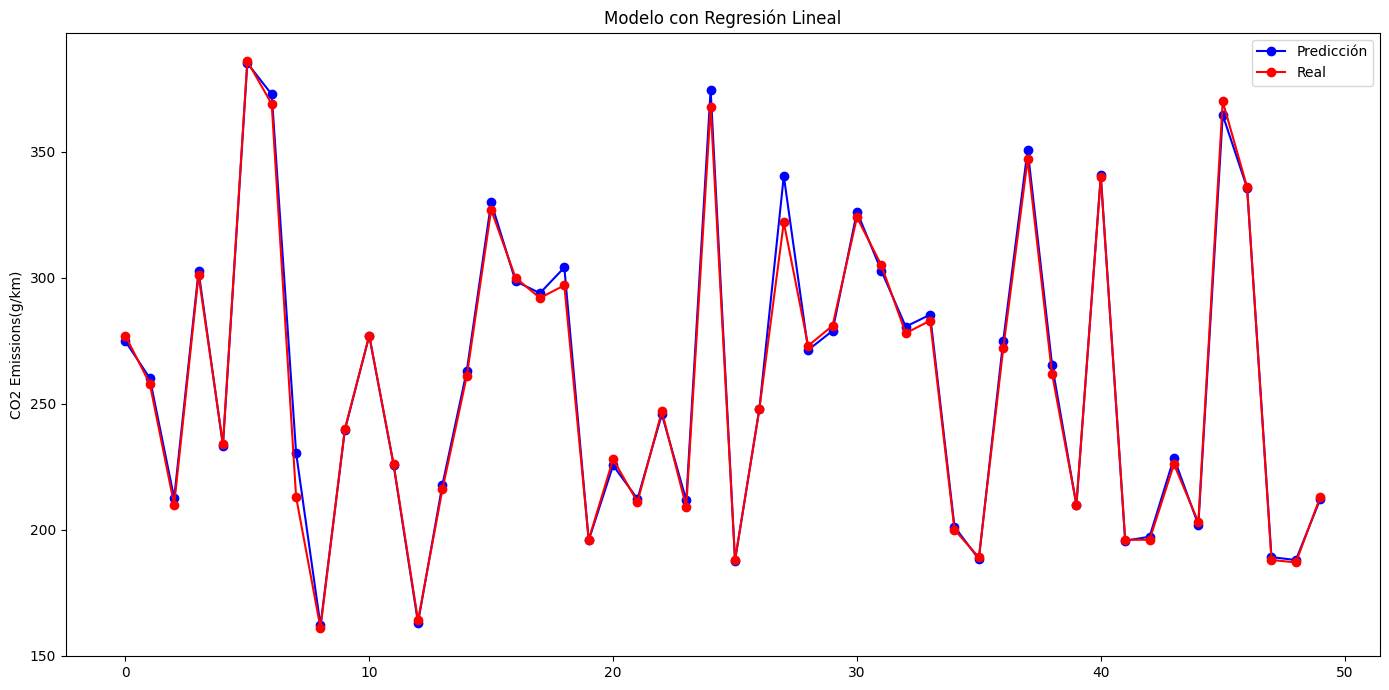

In [ ]:
fig, axs = plt.subplots(1,figsize=(14,7))

xvals = list(range(len(y_train[:50])))
axs.plot(xvals, y_pred_train_lr[:50],'bo-', label='Predicción')
axs.plot(xvals, y_train[:50],'ro-', label='Real')

axs.set(title='Modelo con Regresión Lineal', ylabel=y_train.name)
axs.legend()

plt.tight_layout()
plt.show()

**Veamos como se comporta el modelo con datos desconocidos**

In [ ]:
y_pred_test_lr = pipe_lr.predict(X_test)
y_pred_test_lr

array([188.84689365, 270.21104954, 374.26938916, ..., 198.63018832,
       260.30472017, 250.93058065])

In [ ]:
n,p = X_test.shape

print('------------ Regresión Lineal ------------')
print("Sum of squares (MSE): %.2f" % mean_squared_error(y_test, y_pred_test_lr))
print("Root of sum of squares (RMSE): %.2f" % mean_squared_error(y_test, y_pred_test_lr) ** (1/2))
print("R2-score: %.5f" % r2_score(y_test, y_pred_test_lr) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_test, y_pred_test_lr))*(n-1)/(n-p-1)) )

------------ Regresión Lineal ------------
Sum of squares (MSE): 22.53
Root of sum of squares (RMSE): 4.75
R2-score: 0.99302
Adj R2-score: 0.99298


## 2.2. Regresión Polinomial

In [ ]:
estimators_poly = [
        ('transform',preprocessor),
        ('poly',PolynomialFeatures(degree=3)),
        ('regression', LinearRegression())
]

pipe_poly = Pipeline(estimators_poly)

pipe_poly.fit(X_train, y_train)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29350>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   FunctionTransformer(func=<function fix_cat_values at 0x78fbb2f58e00>)),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29610>)])),
                ('poly', PolynomialFeatures(degree=3)),
                ('regression', LinearRegression())])

In [ ]:
coef_lr = dict(zip(col_names, pipe_poly["regression"].coef_))
for k,v in coef_lr.items():
    print(f'{k} = {v:,.2f}')

Engine Size(L) = 0.00
Cylinders = 0.01
Fuel Consumption City (L/100 km) = 0.00
Fuel Consumption Hwy (L/100 km) = 0.02
Fuel Consumption Comb (L/100 km) = 0.01
Fuel Consumption Comb (mpg) = 0.02
Make_ACURA = -0.04
Make_ALFA ROMEO = -0.00
Make_ASTON MARTIN = -0.00
Make_AUDI = -0.00
Make_BENTLEY = -0.00
Make_BMW = 0.00
Make_BUGATTI = -0.00
Make_BUICK = 0.00
Make_CADILLAC = -0.00
Make_CHEVROLET = -0.00
Make_CHRYSLER = -0.00
Make_DODGE = -0.00
Make_FIAT = 0.00
Make_FORD = -0.00
Make_GENESIS = 0.00
Make_GMC = 0.00
Make_HONDA = -0.00
Make_HYUNDAI = 0.00
Make_INFINITI = 0.00
Make_JAGUAR = -0.00
Make_JEEP = 0.00
Make_KIA = 0.00
Make_LAMBORGHINI = -0.00
Make_LAND ROVER = -0.00
Make_LEXUS = -0.00
Make_LINCOLN = -0.00
Make_MASERATI = -0.00
Make_MAZDA = -0.00
Make_MERCEDES-BENZ = -0.00
Make_MINI = 0.00
Make_MITSUBISHI = -0.00
Make_NISSAN = -0.00
Make_PORSCHE = 0.00
Make_RAM = -0.00
Make_ROLLS-ROYCE = -0.00
Make_SCION = 0.00
Make_SMART = -0.00
Make_SRT = -0.00
Make_SUBARU = 0.00
Make_TOYOTA = -0.00
M

**Evaluemos el modelo**

In [ ]:
y_pred_train_poly = pipe_poly.predict(X_train)
y_pred_train_poly

array([275.21004132, 256.8419214 , 211.53195347, ..., 248.90724051,
       313.45779801, 272.59371407])

In [ ]:
n,p = X_train.shape

print('------------ Regresión Lineal ------------')
print("Sum of squares (MSE): %.2f" % mean_squared_error(y_train, y_pred_train_poly))
print("Root of sum of squares (RMSE): %.2f" % mean_squared_error(y_train, y_pred_train_poly) ** (1/2))
print("R2-score: %.5f" % r2_score(y_train, y_pred_train_poly) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_train, y_pred_train_poly))*(n-1)/(n-p-1)) )

------------ Regresión Lineal ------------
Sum of squares (MSE): 6.70
Root of sum of squares (RMSE): 2.59
R2-score: 0.99812
Adj R2-score: 0.99811


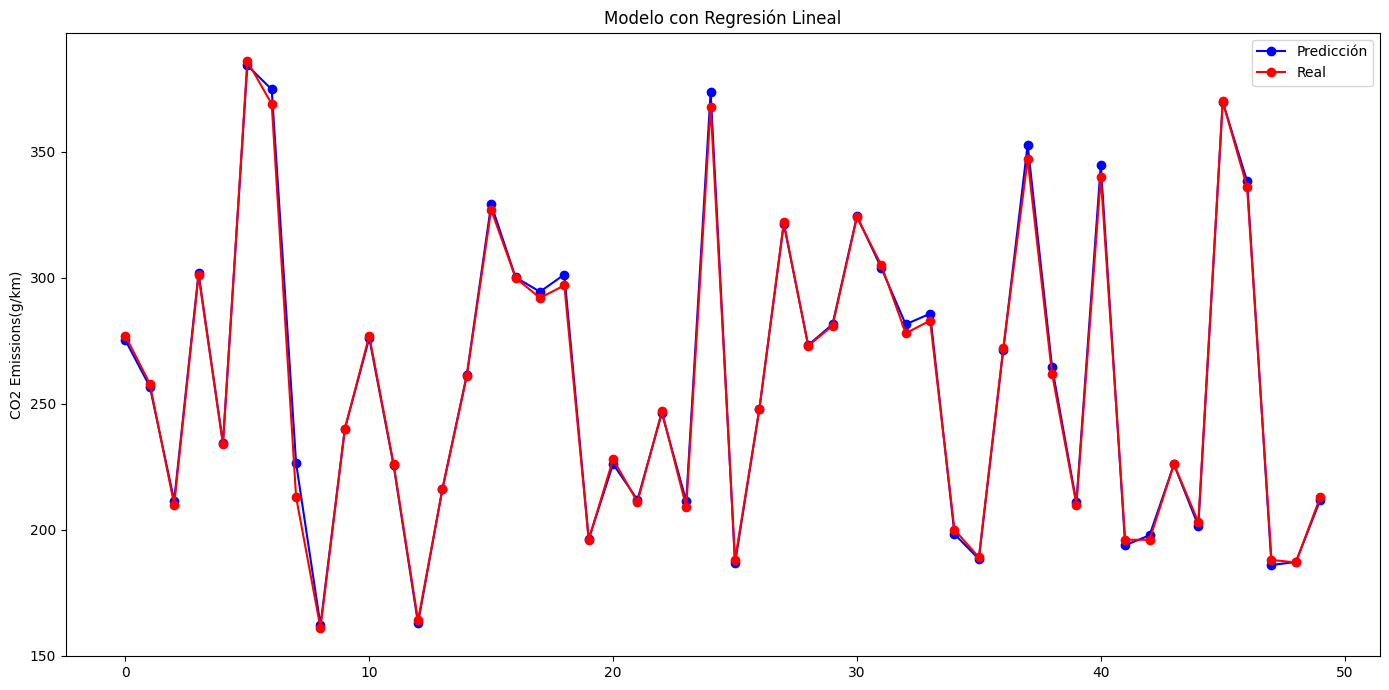

In [ ]:
fig, axs = plt.subplots(1,figsize=(14,7))

xvals = list(range(len(y_train[:50])))
axs.plot(xvals, y_pred_train_poly[:50],'bo-', label='Predicción')
axs.plot(xvals, y_train[:50],'ro-', label='Real')

axs.set(title='Modelo con transformación polinomial', ylabel=y_train.name)
axs.legend()

plt.tight_layout()
plt.show()

**Veamos como se comporta el modelo con datos desconocidos**

In [ ]:
y_pred_test_poly = pipe_poly.predict(X_test)
y_pred_test_poly

array([186.65013393, 267.85243875, 377.69199543, ..., 199.23669193,
       258.42778448, 249.05293586])

In [ ]:
n,p = X_test.shape

print('------------ Regresión Lineal ------------')
print("Sum of squares (MSE): %.2f" % mean_squared_error(y_test, y_pred_test_poly))
print("Root of sum of squares (RMSE): %.2f" % mean_squared_error(y_test, y_pred_test_poly) ** (1/2))
print("R2-score: %.5f" % r2_score(y_test, y_pred_test_poly) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_test, y_pred_test_poly))*(n-1)/(n-p-1)) )

------------ Regresión Lineal ------------
Sum of squares (MSE): 7.17
Root of sum of squares (RMSE): 2.68
R2-score: 0.99778
Adj R2-score: 0.99777


## 2.3. Regresión Lineal con Regularización L1

In [ ]:
estimators_lasso = [
        ('transform',preprocessor),
        ('lasso', Lasso(alpha=8))
]

pipe_lasso = Pipeline(estimators_lasso)

pipe_lasso.fit(X_train, y_train)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29350>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   FunctionTransformer(func=<function fix_cat_values at 0x78fbb2f58e00>)),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29610>)])),
                ('lasso', Lasso(alpha=8))])

In [ ]:
coef_lr = dict(zip(col_names, pipe_lasso["lasso"].coef_))
for k,v in coef_lr.items():
    print(f'{k} = {v:,.2f}')

Engine Size(L) = 0.00
Cylinders = 5.83
Fuel Consumption City (L/100 km) = 4.16
Fuel Consumption Hwy (L/100 km) = 0.00
Fuel Consumption Comb (L/100 km) = 0.00
Fuel Consumption Comb (mpg) = -4.32
Make_ACURA = -0.00
Make_ALFA ROMEO = -0.00
Make_ASTON MARTIN = 0.00
Make_AUDI = -0.00
Make_BENTLEY = 0.00
Make_BMW = -0.00
Make_BUGATTI = 0.00
Make_BUICK = -0.00
Make_CADILLAC = 0.00
Make_CHEVROLET = -0.00
Make_CHRYSLER = -0.00
Make_DODGE = -0.00
Make_FIAT = -0.00
Make_FORD = -0.00
Make_GENESIS = 0.00
Make_GMC = 0.00
Make_HONDA = -0.00
Make_HYUNDAI = 0.00
Make_INFINITI = -0.00
Make_JAGUAR = -0.00
Make_JEEP = 0.00
Make_KIA = 0.00
Make_LAMBORGHINI = 0.00
Make_LAND ROVER = 0.00
Make_LEXUS = -0.00
Make_LINCOLN = 0.00
Make_MASERATI = 0.00
Make_MAZDA = -0.00
Make_MERCEDES-BENZ = 0.00
Make_MINI = -0.00
Make_MITSUBISHI = -0.00
Make_NISSAN = 0.00
Make_PORSCHE = -0.00
Make_RAM = 0.00
Make_ROLLS-ROYCE = 0.00
Make_SCION = -0.00
Make_SMART = 0.00
Make_SRT = 0.00
Make_SUBARU = -0.00
Make_TOYOTA = 0.00
Make_VO

**Evaluemos el modelo**

In [ ]:
y_pred_train_lasso = pipe_lasso.predict(X_train)
y_pred_train_lasso

array([271.15268146, 260.43679768, 223.44708875, ..., 260.43679768,
       304.9302478 , 326.76847785])

In [ ]:
n,p = X_train.shape

print('------------ Regresión Lineal ------------')
print("Sum of squares (MSE): %.2f" % mean_squared_error(y_train, y_pred_train_lasso))
print("Root of sum of squares (RMSE): %.2f" % mean_squared_error(y_train, y_pred_train_lasso) ** (1/2))
print("R2-score: %.5f" % r2_score(y_train, y_pred_train_lasso) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_train, y_pred_train_lasso))*(n-1)/(n-p-1)) )

------------ Regresión Lineal ------------
Sum of squares (MSE): 392.65
Root of sum of squares (RMSE): 19.82
R2-score: 0.88958
Adj R2-score: 0.88939


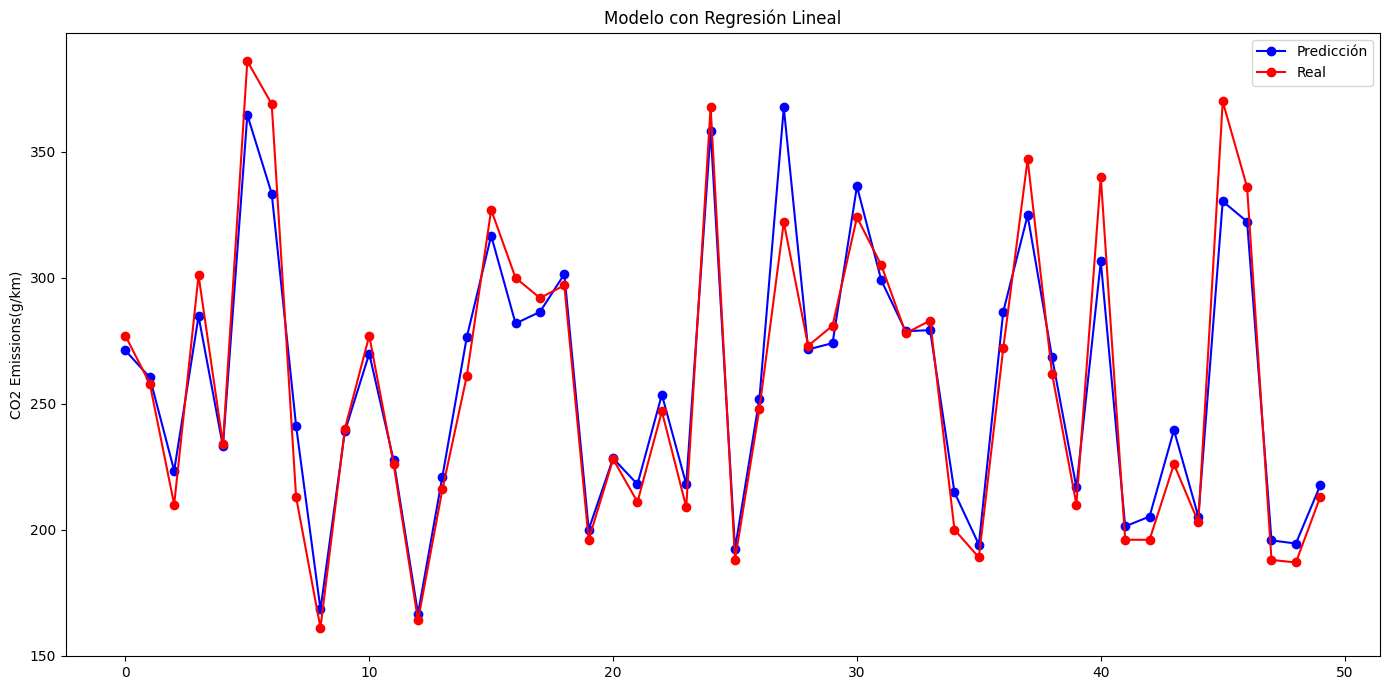

In [ ]:
fig, axs = plt.subplots(1,figsize=(14,7))

xvals = list(range(len(y_train[:50])))
axs.plot(xvals, y_pred_train_lasso[:50],'bo-', label='Predicción')
axs.plot(xvals, y_train[:50],'ro-', label='Real')

axs.set(title='Modelo con transformación lasso', ylabel=y_train.name)
axs.legend()

plt.tight_layout()
plt.show()

**Veamos como se comporta el modelo con datos desconocidos**

In [ ]:
y_pred_test_lasso = pipe_lasso.predict(X_test)
y_pred_test_lasso

array([193.67892699, 267.66820886, 334.27221904, ..., 205.64379029,
       263.08861726, 257.93883862])

In [ ]:
n,p = X_test.shape

print('------------ Regresión Lineal ------------')
print("Sum of squares (MSE): %.2f" % mean_squared_error(y_test, y_pred_test_lasso))
print("Root of sum of squares (RMSE): %.2f" % mean_squared_error(y_test, y_pred_test_lasso) ** (1/2))
print("R2-score: %.5f" % r2_score(y_test, y_pred_test_lasso) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_test, y_pred_test_lasso))*(n-1)/(n-p-1)) )

------------ Regresión Lineal ------------
Sum of squares (MSE): 360.04
Root of sum of squares (RMSE): 18.97
R2-score: 0.88847
Adj R2-score: 0.88776


## 2.4. Búsqueda del mejor modelo

En este caso no solo usaremos un único modelo, sino diferentes combinaciones posibles. Para esto usamos Grid Search CV

In [ ]:
estimators_best = [
        ('transform', preprocessor),
        ('polinomial',PolynomialFeatures()),
        ('regression', Lasso())
]

pipe_best = Pipeline(estimators_best)

# Parametros de la busqueda
parameters = {
              'polinomial__degree':[2,3],
              'regression__alpha': [0.001, 0.01, 1],
              'transform__num': [StandardScaler(), MinMaxScaler(), 'passthrough'],
              'transform__cat': [OneHotEncoder(handle_unknown='ignore'), OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=0)]
              }

grid_search = GridSearchCV(pipe_best, parameters, verbose=2, scoring='neg_mean_squared_error', cv=5)

In [ ]:
%%time
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 14324.51071304762, tolerance: 1487.4889751867022
  model = cd_fast.sparse_enet_coordinate_descent(


[CV] END polinomial__degree=2, regression__alpha=0.001, transform__cat=OneHotEncoder(handle_unknown='ignore'), transform__num=StandardScaler(); total time=  10.2s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 14833.300304981844, tolerance: 1435.5539847747534
  model = cd_fast.sparse_enet_coordinate_descent(


[CV] END polinomial__degree=2, regression__alpha=0.001, transform__cat=OneHotEncoder(handle_unknown='ignore'), transform__num=StandardScaler(); total time=   9.5s


...

[CV] END polinomial__degree=3, regression__alpha=1, transform__cat=OneHotEncoder(handle_unknown='ignore'), transform__num=passthrough; total time=  46.3s
[CV] END polinomial__degree=3, regression__alpha=1, transform__cat=OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=0), transform__num=StandardScaler(); total time=   0.0s
[CV] END polinomial__degree=3, regression__alpha=1, transform__cat=OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=0), transform__num=StandardScaler(); total time=   0.0s
[CV] END polinomial__degree=3, regression__alpha=1, transform__cat=OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=0), transform__num=StandardScaler(); total time=   0.0s
[CV] END polinomial__degree=3, regression__alpha=1, transform__cat=OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=0), transform__num=StandardScaler(); total time=   0.0s
[CV] END polinomial__degree=3, regression__alpha=1, transform__cat=OrdinalEncoder(handle_unkno

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, 

CPU times: user 38min 30s, sys: 3.58 s, total: 38min 34s
Wall time: 39min 13s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 23040.78365620751, tolerance: 1845.251659934477
  model = cd_fast.sparse_enet_coordinate_descent(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transform',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x78fbb2d29350>),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          FunctionTransformer(func=<function fix_cat_values at 0x78fbb2f58e00>)),
                                                                                         ('encoder',
                                                                                          OneHotEncoder...
                                       ('polinomial', PolynomialFeatures()),
                                       ('regression', Lasso())]),
             param_grid={'polinomial__degree': [2, 3],
                         'regression__alpha': [0.001, 0.01, 1],
                         'transform__cat': [OneHotEncoder(handle_unknown='ignore'),
                                            OrdinalEncoder(handle_unknown='use_encoded_value',
                                                           unknown_value=0)],
                         'transform__num': [StandardScaler(), MinMaxScaler(),
                                            'passthrough']},
             scoring='neg_mean_squared_error', verbose=2)

In [ ]:
best_model = grid_search.best_estimator_

pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_polinomial__degree,param_regression__alpha,param_transform__cat,param_transform__num,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,9.695098,0.376826,0.011200,0.000833,2,0.001,OneHotEncoder(handle_unknown='ignore'),StandardScaler(),"{'polinomial__degree': 2, 'regression__alpha':...",-8.788903,-6.671818,-7.359288,-11.685914,-12.182026,-9.337590,2.232779,2
1,8.792279,0.405747,0.011056,0.001776,2,0.001,OneHotEncoder(handle_unknown='ignore'),MinMaxScaler(),"{'polinomial__degree': 2, 'regression__alpha':...",-9.035447,-6.613707,-7.533025,-11.346874,-12.364604,-9.378731,2.189012,3
2,10.397811,1.550233,0.012407,0.002181,2,0.001,OneHotEncoder(handle_unknown='ignore'),passthrough,"{'polinomial__degree': 2, 'regression__alpha':...",-8.952868,-8.535856,-7.459722,-9.977228,-12.592461,-9.503627,1.742565,4
3,0.008792,0.000450,0.000000,0.000000,2,0.001,OrdinalEncoder(handle_unknown='use_encoded_val...,StandardScaler(),"{'polinomial__degree': 2, 'regression__alpha':...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,19
4,0.008688,0.000264,0.000000,0.000000,2,0.001,OrdinalEncoder(handle_unknown='use_encoded_val...,MinMaxScaler(),"{'polinomial__degree': 2, 'regression__alpha':...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,19
5,0.006459,0.000385,0.000000,0.000000,2,0.001,OrdinalEncoder(handle_unknown='use_encoded_val...,passthrough,"{'polinomial__degree': 2, 'regression__alpha':...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,19
6,9.039237,0.568518,0.023308,0.016292,2,0.010,OneHotEncoder(handle_unknown='ignore'),StandardScaler(),"{'polinomial__degree': 2, 'regression__alpha':...",-7.737650,-7.012733,-7.917912,-13.656848,-11.673110,-9.599650,2.597981,5
7,8.459613,0.493010,0.014313,0.003468,2,0.010,OneHotEncoder(handle_unknown='ignore'),MinMaxScaler(),"{'polinomial__degree': 2, 'regression__alpha':...",-8.649642,-7.461745,-8.704221,-13.961796,-12.980147,-10.351510,2.604018,12
8,9.725174,0.605044,0.021445,0.014088,2,0.010,OneHotEncoder(handle_unknown='ignore'),passthrough,"{'polinomial__degree': 2, 'regression__alpha':...",-7.928653,-7.183592,-7.851460,-10.114307,-11.838359,-8.983274,1.735675,1
9,0.036909,0.010767,0.000000,0.000000,2,0.010,OrdinalEncoder(handle_unknown='use_encoded_val...,StandardScaler(),"{'polinomial__degree': 2, 'regression__alpha':...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,19


In [ ]:
grid_search.best_params_

{'polinomial__degree': 2,
 'regression__alpha': 0.01,
 'transform__cat': OneHotEncoder(handle_unknown='ignore'),
 'transform__num': 'passthrough'}

**Evaluación final**

In [ ]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)
y_pred_train

array([275.476549  , 256.01467685, 211.05845135, ..., 250.24867305,
       312.79808857, 271.42069162])

In [ ]:
n,p = X_train.shape

print('------------ Regresión Lasso con entrenamiento------------')
print("Residual sum of squares (MSE): %.2f" % mean_squared_error(y_train, y_pred_train))
print("R2-score: %.5f" % r2_score(y_train, y_pred_train) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_train, y_pred_train))*(n-1)/(n-p-1)) )

n,p = X_test.shape

print('------------ Regresión Lasso con evaluación ------------')
print("Residual sum of squares (MSE): %.2f" % mean_squared_error(y_test, y_pred_test))
print("R2-score: %.5f" % r2_score(y_test, y_pred_test) )
print("Adj R2-score: %.5f" % ( 1-(1-r2_score(y_test, y_pred_test))*(n-1)/(n-p-1)) )

------------ Regresión Lasso con entrenamiento------------
Residual sum of squares (MSE): 7.56
R2-score: 0.99787
Adj R2-score: 0.99787
------------ Regresión Lasso con evaluación ------------
Residual sum of squares (MSE): 6.88
R2-score: 0.99787
Adj R2-score: 0.99785


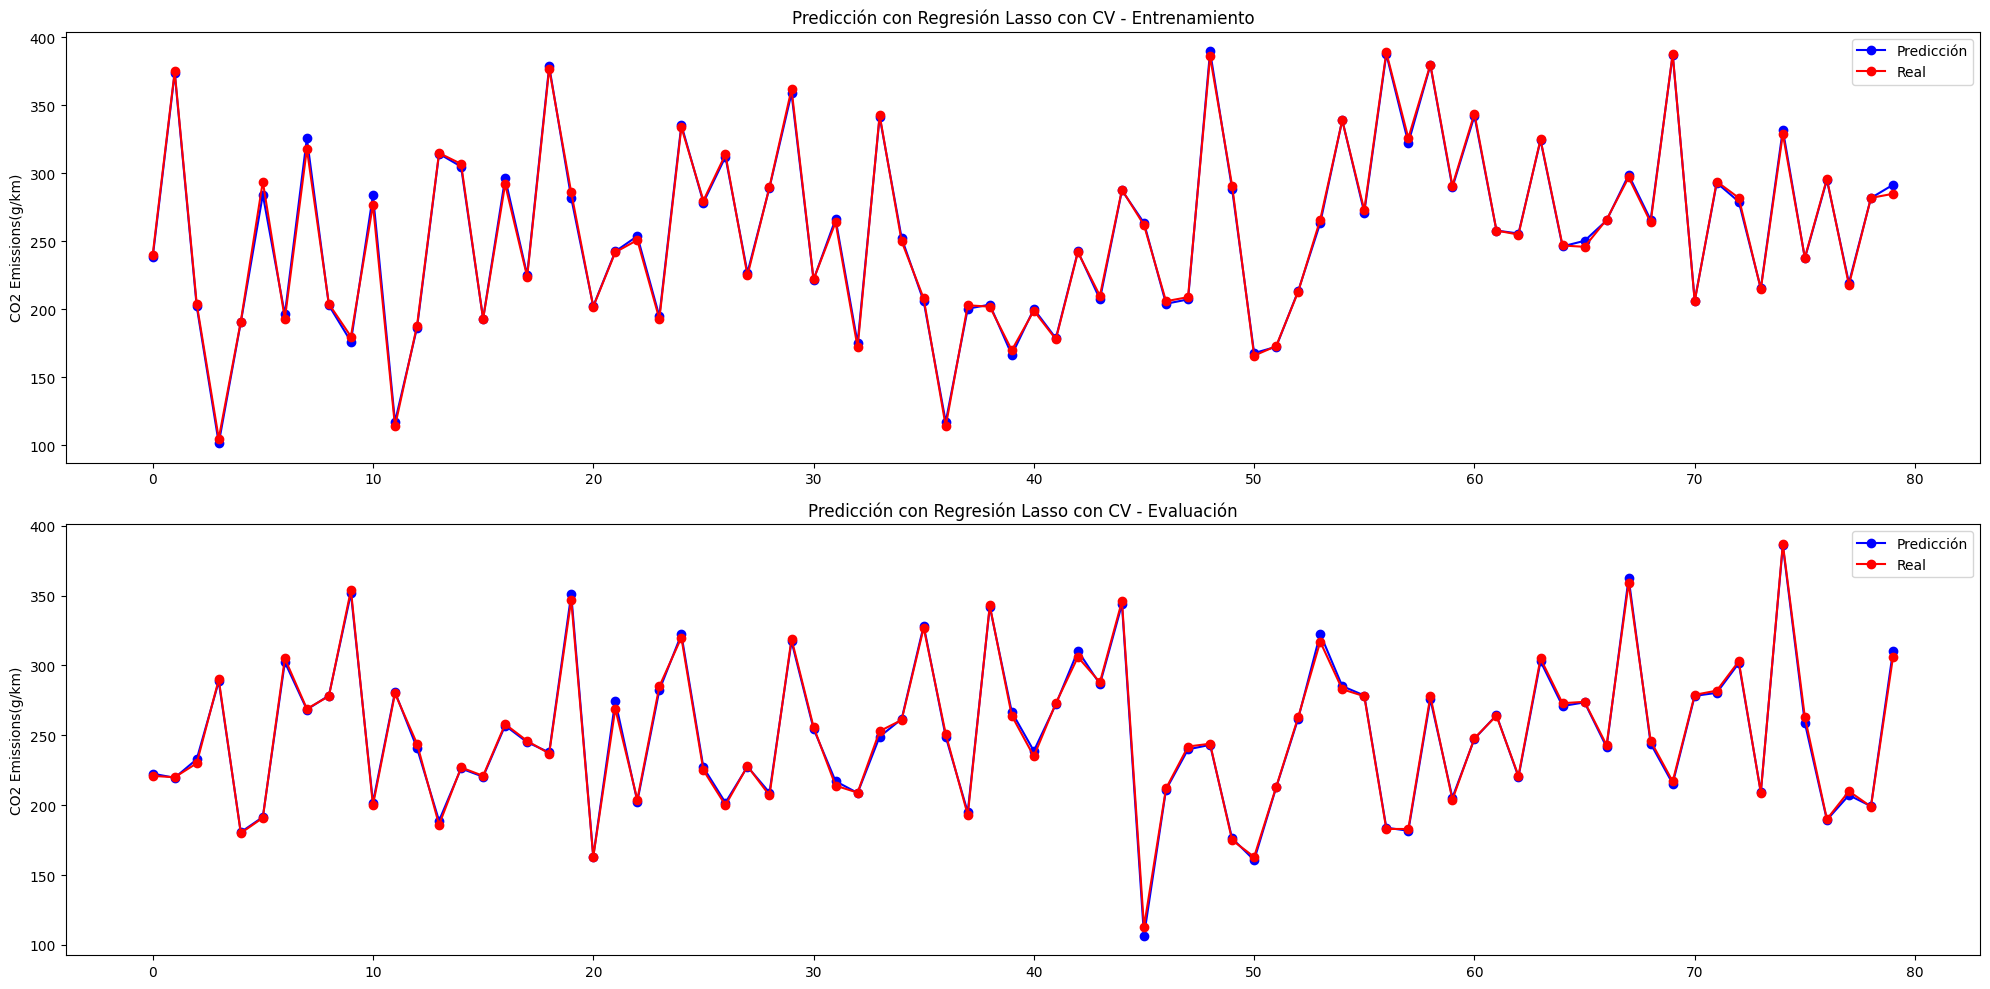

In [ ]:
%matplotlib inline
fig, axs = plt.subplots(2,figsize=(20,10))
a = 1000
b= 1080

xvals = list(range(b-a))
axs[0].plot(xvals, y_pred_train[a:b],'bo-', label='Predicción')
axs[0].plot(xvals, y_train[a:b],'ro-', label='Real')

axs[1].plot(xvals, y_pred_test[a:b],'bo-', label='Predicción')
axs[1].plot(xvals, y_test[a:b],'ro-', label='Real')

axs[0].set(title='Predicción con Regresión Lasso con CV - Entrenamiento', ylabel=y_train.name)
axs[0].legend()

axs[1].set(title='Predicción con Regresión Lasso con CV - Evaluación', ylabel=y_train.name)
axs[1].legend()

plt.tight_layout()
plt.show()

Ya con nuestro mejor modelo encontrado y teniendo un rendimiento esperado en producción, podremos determinar la importancia de las variables del modelo. Para ello se obtuvo el siguiente resultado.

In [ ]:
lasso_model = best_model['regression']
trans_df = best_model['transform'].transform(X_test)
fake_df = best_model['polinomial'].transform(trans_df)

cat_names = best_model['transform'].transformers_[1][1].get_feature_names_out()
num_names = best_model['transform'].transformers_[0][2]#.feature_names_in_
col_names = list(num_names) + list(cat_names)

print(f'Intercepto: {lasso_model.intercept_}')
coef = list(zip(['Intercepto'] + list(col_names), [lasso_model.intercept_] + list(lasso_model.coef_)))
coef = pd.DataFrame(coef,columns=['Variable','Parámetro'])
coef

Intercepto: -3.169308956305315


,Variable,Parámetro
0,Intercepto,-3.169309
1,Engine Size(L),0.000000
2,Cylinders,25.315855
3,Fuel Consumption City (L/100 km),2.306373
4,Fuel Consumption Hwy (L/100 km),9.742860
...,...,...
76,Fuel Type_D,-0.000000
77,Fuel Type_E,0.000000
78,Fuel Type_N,-0.000000
79,Fuel Type_X,-0.000000


-------------
# 3. Preguntas

1. Cree un pipeline con el algoritmo de su seleccion donde incluya un minmaxScaler a las variables que aplique

In [ ]:
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', MinMaxScaler())  # Adicion aca
    ]
)

cat_transformer = Pipeline(
    steps=[
        ('imputer', FunctionTransformer(fix_cat_values, validate=False)),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", cat_transformer, make_column_selector(dtype_include=object))
    ]
)


2. Cuáles diferencias son las mas significativas entre una Regresión Lineal Simple, con transformación Polinomial o con regularización L1?

Respuesta:

3. ¿Qué otro espacio de búsqueda o hiperparámetros serían buenos de buscar en este modelo?.

Respuesta: